# Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.feature_extraction.text import CountVectorizer  #DT does not take strings as input for the model fit step....
from IPython.display import Image
#import pydotplus as pydot
from sklearn import tree
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler


# Data Cleaning

In [2]:
url = 'https://raw.githubusercontent.com/finsaccount/Intrusion-Detection-System-Machine-Learning/refs/heads/main/data%202.csv'
data = pd.read_csv(url)

In [3]:
print(data['label2'].unique())

['attack' 'benign']


In [4]:
labels_dict={'attack':1, 'benign':0}
data['label2'] = data['label2'].map(labels_dict)


In [5]:
data.shape

(1726, 73)

# Getting Data (Splitting for Train and Test)




In [6]:
data = data.dropna()
data = data.drop('label', axis=1)
data.head()

,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_fragmented-packets,network_fragmentation-score,...,network_packets_dst_count,network_interval-packets,log_messages_count,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,timeDurationInSeconds,label2
0,63.000000,64.0,62.0,1.000017,20.0,20.0,20.0,0.0,0,0,...,14750,3108.335228,29500,0,0,0,0,0,10,1
1,62.999877,64.0,61.0,1.000246,20.0,20.0,20.0,0.0,0,0,...,4065,914.745196,8133,0,0,0,0,0,10,1
2,62.675676,64.0,62.0,0.949158,20.0,20.0,20.0,0.0,0,0,...,98,30.766254,148,0,0,0,0,0,10,1
3,63.000000,64.0,62.0,1.000023,20.0,20.0,20.0,0.0,0,0,...,11080,2500.940731,22160,0,0,0,0,0,10,1
5,62.857143,64.0,62.0,1.069045,20.0,20.0,20.0,0.0,0,0,...,4,0.707193,7,0,0,0,0,0,10,1


In [7]:

X = data.drop('label2', axis=1)
Y = data.pop('label2')
x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.3,
                                                    random_state=123,
                                                    shuffle=True)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [8]:
def getAccuracy(testSet, predictions):
  correct = sum(1 for a, b in zip(testSet, predictions) if a==b)
  return (correct/float(len(testSet)))*100.0

In [9]:
import pandas as pd
import numpy as np
from sklearn import svm, metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import string
%matplotlib inline

## Hyperparameter Tunning

In [10]:
C_values = [0.1, 1, 3, 10]
gamma_values = [0.001, 0.01, 0.025, 0.1]
results = []
for C in C_values:
    for gamma in gamma_values:
        clf = svm.SVC(C=C, gamma=gamma)
        clf.fit(x_train_scaled, y_train)
        y_pred = clf.predict(x_test_scaled)
        acc = getAccuracy(y_test, y_pred)
        results.append((C, gamma, acc))
        print(f"C={C:5}, gamma={gamma:.3f}  →  Accuracy: {acc:.2f}%")

C=  0.1, gamma=0.001  →  Accuracy: 82.11%
C=  0.1, gamma=0.010  →  Accuracy: 84.96%
C=  0.1, gamma=0.025  →  Accuracy: 87.20%
C=  0.1, gamma=0.100  →  Accuracy: 90.85%
C=    1, gamma=0.001  →  Accuracy: 85.16%
C=    1, gamma=0.010  →  Accuracy: 92.48%
C=    1, gamma=0.025  →  Accuracy: 94.51%
C=    1, gamma=0.100  →  Accuracy: 96.34%
C=    3, gamma=0.001  →  Accuracy: 87.20%
C=    3, gamma=0.010  →  Accuracy: 93.29%
C=    3, gamma=0.025  →  Accuracy: 96.75%
C=    3, gamma=0.100  →  Accuracy: 96.75%
C=   10, gamma=0.001  →  Accuracy: 90.65%
C=   10, gamma=0.010  →  Accuracy: 95.93%
C=   10, gamma=0.025  →  Accuracy: 97.56%
C=   10, gamma=0.100  →  Accuracy: 97.15%


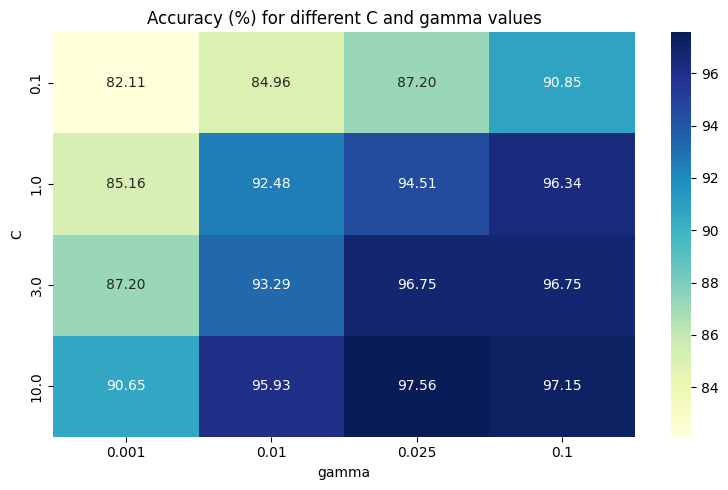

In [11]:
acc_matrix = np.array([r[2] for r in results]).reshape(len(C_values), len(gamma_values))
df_results = pd.DataFrame(acc_matrix, index=C_values, columns=gamma_values)

plt.figure(figsize=(8, 5))
sns.heatmap(df_results, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Accuracy (%) for different C and gamma values')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

In [12]:
clf = svm.SVC(kernel='linear', C=3, gamma=0.025)
clf.fit(x_train_scaled, y_train)
y_pred = clf.predict(x_test_scaled)
acc = getAccuracy(y_test, y_pred)
linearResults = acc

In [13]:
clf = svm.SVC(kernel='rbf', C=3, gamma=0.025)
clf.fit(x_train_scaled, y_train)
y_pred = clf.predict(x_test_scaled)
acc = getAccuracy(y_test, y_pred)
rgfResults = acc

In [14]:
clf = svm.SVC(kernel='sigmoid', C=3, gamma=0.025)
clf.fit(x_train_scaled, y_train)
y_pred = clf.predict(x_test_scaled)
acc = getAccuracy(y_test, y_pred)
sigResults = acc

In [15]:
kernels = ['linear', 'rbf', 'sigmoid']
kernel_results = {}

for kernel in kernels:

    kernel_results[kernel] = acc
    print(f"Kernel: {kernel:8}  →  Accuracy: {acc:.2f}%")

Kernel: linear    →  Accuracy: 73.58%
Kernel: rbf       →  Accuracy: 73.58%
Kernel: sigmoid   →  Accuracy: 73.58%


In [16]:
print(f'Kernel: linear, -> accuracy:{linearResults}')
print(f'Kernel: RGB, -> accuracy:{rgfResults}')
print(f'Kernel: sigmoid -> accuracy:{sigResults}')

Kernel: linear, -> accuracy:93.29268292682927
Kernel: RGB, -> accuracy:96.7479674796748
Kernel: sigmoid -> accuracy:73.57723577235772


# Hyper Parameter Searching for Best Values (with scikit-learn)

In [17]:
from sklearn.svm import SVC
print("LINEAR")
model = SVC(kernel='linear')
model.fit(x_train_scaled, y_train)
predictions = model.predict(x_test_scaled)
print(classification_report(y_test, predictions))
print("-"*50)
print("RBF")
model = SVC(kernel='rbf')
model.fit(x_train_scaled, y_train)
predictions = model.predict(x_test_scaled)
print(classification_report(y_test, predictions))
print("-"*50)
print("sigmoid")
model = SVC(kernel='sigmoid')
model.fit(x_train_scaled, y_train)
predictions = model.predict(x_test_scaled)
print(classification_report(y_test, predictions))
print("-"*50)
print("poly")
# model = SVC(kernel='poly')
# model.fit(x_train_scaled, y_train)
# predictions = model.predict(x_test_scaled)
# print(classification_report(y_test, predictions))

LINEAR
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       221
           1       0.90      0.96      0.93       271

    accuracy                           0.92       492
   macro avg       0.92      0.91      0.91       492
weighted avg       0.92      0.92      0.92       492

--------------------------------------------------
RBF
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       221
           1       0.90      0.99      0.94       271

    accuracy                           0.93       492
   macro avg       0.94      0.92      0.93       492
weighted avg       0.94      0.93      0.93       492

--------------------------------------------------
sigmoid
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       221
           1       0.84      0.82      0.83       271

    accuracy                           0.81       492
   macr

In [18]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [1,10,100],
			'gamma': [0.01,0.1,1],
			'kernel': ['rbf']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
grid.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.917 total time=   0.1s
[CV 2/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.887 total time=   0.1s
[CV 3/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.896 total time=   0.1s
[CV 4/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.908 total time=   0.1s
[CV 5/5] END .......C=1, gamma=0.01, kernel=rbf;, score=0.930 total time=   0.1s
[CV 1/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.957 total time=   0.1s
[CV 2/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.965 total time=   0.1s
[CV 3/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.965 total time=   0.1s
[CV 4/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.974 total time=   0.1s
[CV 5/5] END ........C=1, gamma=0.1, kernel=rbf;, score=0.956 total time=   0.1s
[CV 1/5] END ..........C=1, gamma=1, kernel=rbf;, score=0.913 total time=   0.2s
[CV 2/5] END ..........C=1, gamma=1, kernel=rbf;,

GridSearchCV(estimator=SVC(),
             param_grid={'C': [1, 10, 100], 'gamma': [0.01, 0.1, 1],
                         'kernel': ['rbf']},
             verbose=3)

In [19]:
from sklearn.svm import SVC
model = SVC(kernel='rbf', C=100, gamma = 0.01)
model.fit(x_train_scaled, y_train)
predictions = model.predict(x_test_scaled)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       221
           1       0.97      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.98      0.98       492
weighted avg       0.98      0.98      0.98       492



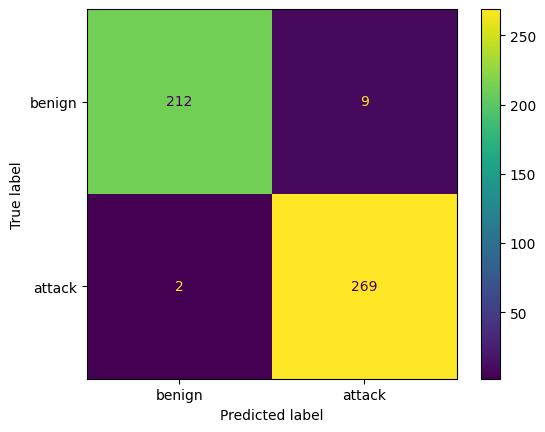

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#  'attack': 1, 'benign': 0
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]

cm = confusion_matrix(y_test, predictions, labels=y_test.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()

In [21]:
from sklearn.metrics import precision_score, f1_score, balanced_accuracy_score, recall_score
print(precision_score(y_test, predictions))
print(f1_score(y_test, predictions))
print(recall_score(y_test, predictions))
print(balanced_accuracy_score(y_test, predictions))

0.9676258992805755
0.9799635701275046
0.992619926199262
0.9759479721494048


In [22]:
# param_grid = {'C': [0.1, 1, 10, 100, 1000],
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
# 			'kernel': ['linear','poly','rbf','sigmoid']}
# grid2 = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
# grid2.fit(x_train, y_train)
# print(grid2.best_params)

# Summary
`Accuracy = 0.95` with `{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}`